In [14]:
# test spectogram block
import torch

import matplotlib.pyplot as plt
import numpy as np
import random, os


from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.models.blocks.spectrogram import SpectrogramBlock
from thesis_project.utils.paths import get_data_dir

noise_params=[0.00, 0.05, 0.1, 0.15, 0.20, 0.25]

data_dir = get_data_dir()
dataset = SpeechCommandsGoogle(root=str(data_dir), noise_mode='std', noise_params=noise_params, subset="training", download=True)


In [15]:
len(dataset)/len(noise_params)  # number of samples per noise level

14140.5

In [16]:
spec_complex = SpectrogramBlock(sample_rate=16000, power=None, logarithm=False)
spec_magnitude = SpectrogramBlock(sample_rate=16000, power=1.0, logarithm=False)
spec_DB = SpectrogramBlock(sample_rate=16000, power=1.0, logarithm=True)


In [17]:
def process_signal(waveform: torch.Tensor, remove_batch_dim: bool = True):
    """
    Expects waveform with shape [T] or [1, T]. Adds batch dim for STFT ops.
    Returns dict with keys aligned to plotting fn: raw, mag, decibel, phase, real, imag, complex.
    """

    processed = {}

    # Keep a raw (waveform) copy (with/without batch dim depending on flag)
    processed["raw"] = waveform.squeeze(0)

    # Your existing spectral functions
    cpx = spec_complex(waveform)               # -> [B, F, T], complex
    mag = spec_magnitude(waveform)             # -> [B, F, T], real
    db  = spec_DB(waveform)                    # -> [B, F, T], real (dB)

    processed["complex"] = cpx
    processed["mag"]     = mag
    processed["decibel"] = db
    processed["phase"]   = torch.angle(cpx)
    processed["real"]    = torch.real(cpx)
    processed["imag"]    = torch.imag(cpx)

    if remove_batch_dim:
        for k in list(processed.keys()):
            processed[k] = processed[k].squeeze(0)
    return processed

In [18]:
def plot_different_domains(
    processed_signal: dict,
    metadata: dict | None = None,
    title_suffix: str = "",
    domains: list[str] | None = None,
):
    """
    Plot selected signal domains (e.g. ["raw", "mag", "decibel", "phase", "real", "imag"]).

    Args:
        processed_signal: dict from process_signal()
        metadata: optional dict with e.g. {"label": "word"}
        title_suffix: optional string appended to titles
        domains: list of keys to plot; defaults to all available ones
    """
    label = metadata.get("label") if metadata else None

    # Default order of domains
    default_domains = ["raw", "mag", "decibel", "phase", "real", "imag"]
    if domains is None:
        domains = [d for d in default_domains if d in processed_signal]

    n_plots = len(domains)
    fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(10, 3 * n_plots))
    if n_plots == 1:
        axes = [axes]  # make iterable if only one plot

    plt.subplots_adjust(hspace=0.5)

    for i, key in enumerate(domains):
        ax = axes[i]
        value = processed_signal[key]
        if isinstance(value, torch.Tensor):
            value = value.detach().cpu().numpy()

        # ---- 1D waveform ----
        if value.ndim == 1:
            ax.plot(value)
            ax.set_xlabel("Time (samples)")
            ax.set_ylabel("Amplitude")

        # ---- 2D spectrogram-like ----
        elif value.ndim == 2:
            cmap = "viridis"
            if key == "phase":
                cmap = "twilight"
            elif key in ("real", "imag"):
                cmap = "coolwarm"

            im = ax.imshow(value, aspect="auto", origin="lower", cmap=cmap)
            fig.colorbar(im, ax=ax)
            ax.set_xlabel("Time frames")
            ax.set_ylabel("Frequency bins")

        else:
            raise ValueError(f"Unsupported number of dimensions for '{key}': {value.ndim}")

        title = f"{key.upper()} (Word: {label})" if label else key.upper()
        if title_suffix:
            title += f" {title_suffix}"
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


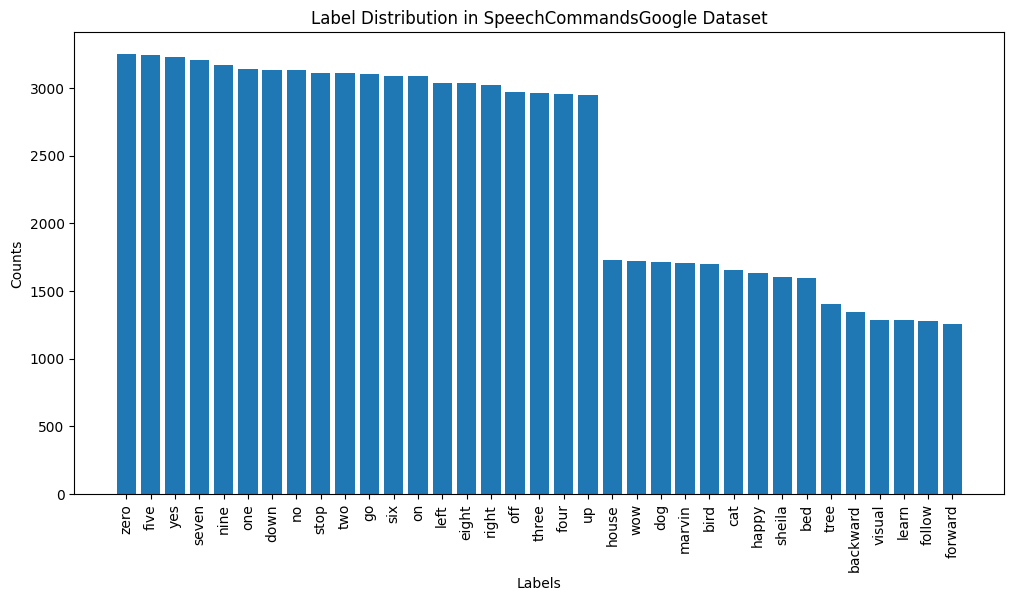

In [25]:
dataset.label_counts.items()
# plot label distribution sorted by occurrence
labels, counts = zip(*sorted(dataset.label_counts.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(12,6))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title("Label Distribution in SpeechCommandsGoogle Dataset")
plt.xlabel("Labels")
plt.ylabel("Counts")
plt.show()


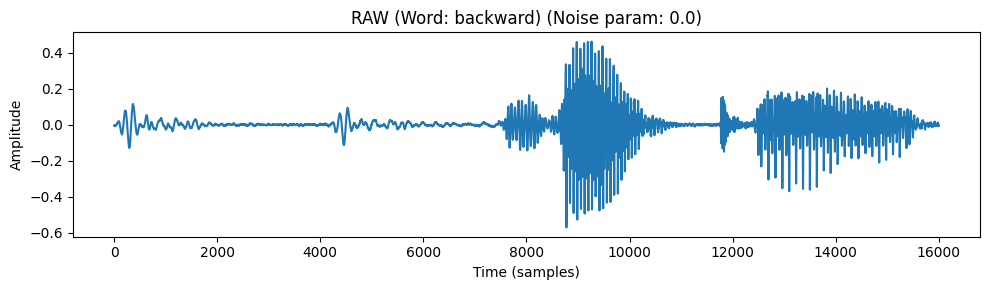

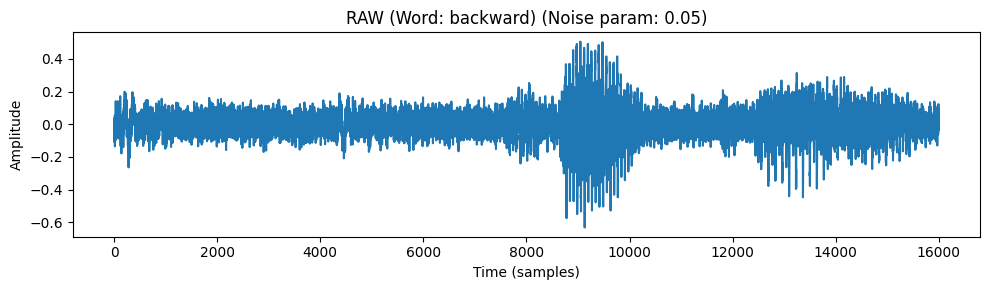

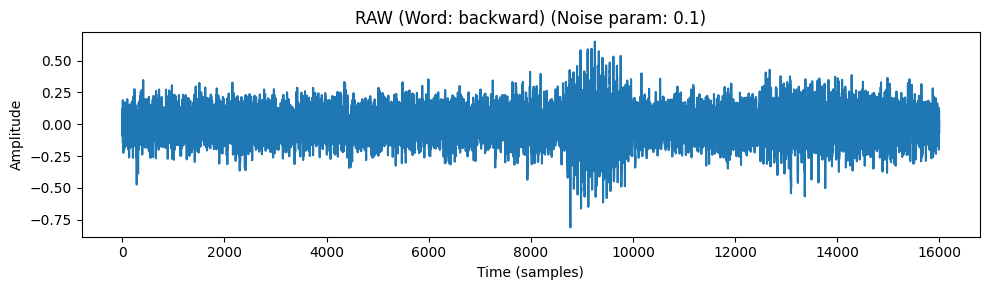

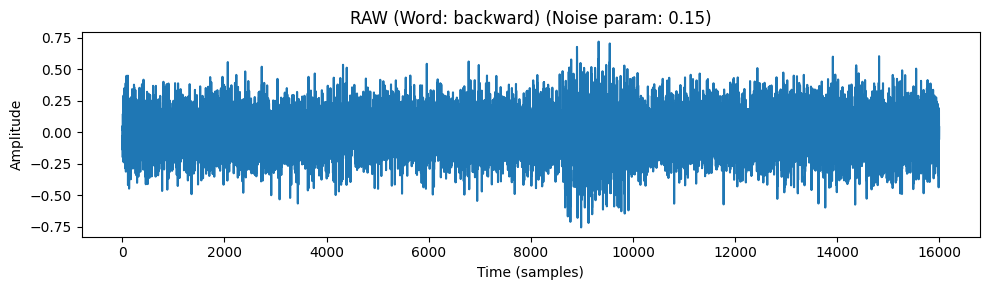

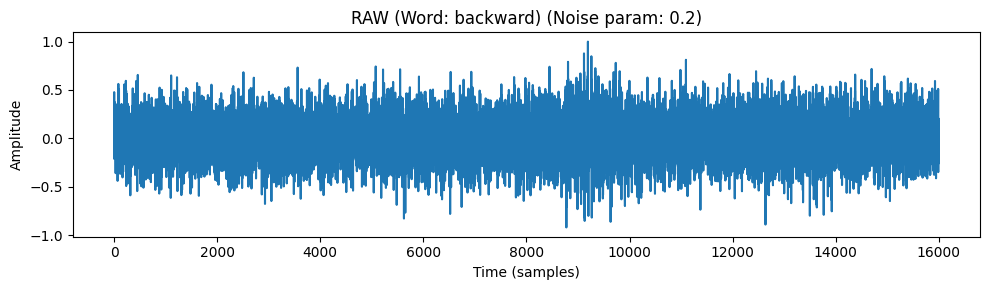

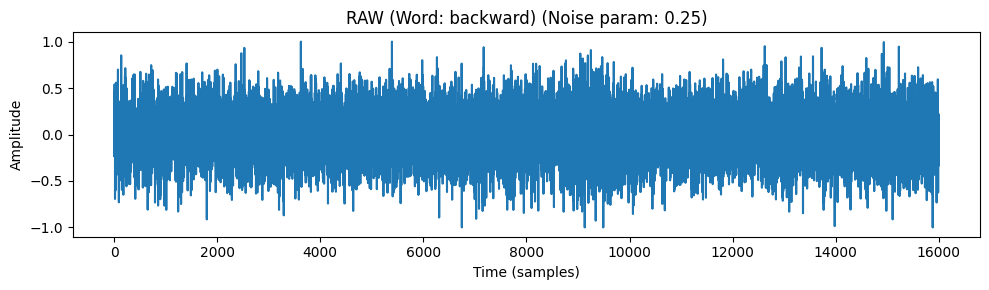

In [23]:
sample_idx = 42  # pick a sample index

noisy_waveforms = []
for noise_param in noise_params:
    waveform, label, metadata = dataset.get_item_with_given_noise_param(sample_idx, noise_param)
    processed = process_signal(waveform)
    plot_different_domains(processed, metadata=metadata, title_suffix=f"(Noise param: {metadata['noise_param']})",domains=["raw"])
    noisy_waveforms.append(waveform)

In [21]:
# play the different waveforms
import IPython.display as ipd
for i, waveform in enumerate(noisy_waveforms):
    print(f"Playing waveform with noise param: {noise_params[i]}")
    ipd.display(ipd.Audio(waveform.numpy(), rate=16000))

Playing waveform with noise param: 0.0


Playing waveform with noise param: 0.05


Playing waveform with noise param: 0.1


Playing waveform with noise param: 0.15


Playing waveform with noise param: 0.2


Playing waveform with noise param: 0.25
